# Reward functions and preprocessing etc...

In [1]:
# ONE on restart
import stable_retro as retro
import gymnasium as gym
from gymnasium import Env
from gymnasium.spaces import MultiBinary, Box
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [ ]:
# start game environment
env = retro.make(game="StreetFighterIISpecialChampionEdition-Genesis-v0")

In [ ]:
# TESTING RENDER ENV
env = retro.make(game="StreetFighterIISpecialChampionEdition-Genesis-v0", render_mode="human")

In [ ]:
# close game environment
env.close()

In [ ]:
env.observation_space

In [ ]:
env.action_space.sample()

In [ ]:
obs, info = env.reset()
terminated = False
truncated = False
for game in range(1):
    while not terminated and not truncated:
        if terminated or truncated:
            obs, info = env.reset()
        env.render()
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
        print(reward)
        print(info)

In [ ]:
obs, info = env.reset()

In [42]:
info

{'continuetimer': 10,
 'enemy_matches_won': 2,
 'enemy_health': 0,
 'health': 0,
 'matches_won': 0,
 'score': 40300}

In [ ]:
# TWO on restart

class StreetFighter(Env):
    def __init__(self):
        super().__init__()
        self.observation_space = Box(low=0, high=255, shape=(84, 84, 1), dtype=np.uint8)
        
        self.action_space = MultiBinary(12)

        self.game = retro.make(game="StreetFighterIISpecialChampionEdition-Genesis-v0", use_restricted_actions=retro.Actions.FILTERED, render_mode=None)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.game.step(action)
        obs = self.preprocess(obs)

        self.previous_frame = obs

        if info["health"] == 0 and info["enemy_health"] == 0:
            reward = 0
            self.enemy_health = 0
            self.player_health = 0
        else:
            dmg_dealt = self.enemy_health -info["enemy_health"]
            dmg_taken = self.player_health- info["health"]
            self.enemy_health = info["enemy_health"]
            self.player_health = info["health"]
            reward = dmg_dealt - dmg_taken
        

        return obs, reward, terminated, truncated, info


    def render(self, *args, **kwargs):
        self.game.render()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        obs, info = self.game.reset(seed=seed, options=options)
        obs = self.preprocess(obs)
        self.previous_frame = obs

        
        info = self.game.data.lookup_all()
        self.player_health = info.get("health", 0)
        self.enemy_health = info.get("enemy_health", 0)
        return obs, info

    def preprocess(self, observation):
        gray = cv2.cvtColor(observation, cv2.COLOR_RGB2GRAY)

        resize = cv2.resize(gray, (84,84), interpolation=cv2.INTER_CUBIC)

        channels = np.reshape(resize, (84,84,1))
        return channels


    def close(self):
        self.game.close()

In [8]:
env.close()

In [3]:
# THREE on restart

env = StreetFighter()

In [13]:
env.observation_space

Box(0, 255, (84, 84, 1), uint8)

In [5]:
env.action_space

MultiBinary(12)

In [4]:
obs, info = env.reset()
terminated = False
truncated = False
pos = 0
neg = 0
for game in range(1):
    while not terminated and not truncated:
        if terminated or truncated:
            obs, info = env.reset()
        env.render()
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
        if reward < 0:
            print(reward)
            neg -= reward
        elif reward > 0:
            print(reward)
            pos += reward
    print("Dealt {} damage total, took {} damage total".format(pos, neg))
            
        # print(info["health"], info["enemy_health"])
        

2026-08-13 23:30:48.753 Python[3960:42557208] ApplePersistenceIgnoreState: Existing state will not be touched. New state will be written to /var/folders/3y/d17yw7495_55b7l5t_hyjczh0000gn/T/org.python.python.savedState


7
-23
-24
28
-25
-36
12
-44
-24
28
18
-7
36
40
41
-10
-15
39
7
-24
-32
29
7
-24
-23
-24
35
-44
-3
-3
Dealt 327 damage total, took 385 damage total


In [11]:
obs, info = env.reset()

In [12]:
obs, reward, terminated, truncated, info = env.step(env.action_space.sample())

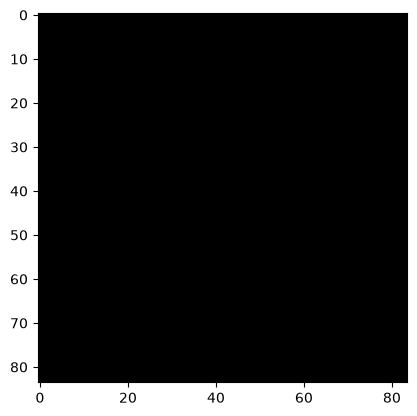

In [40]:
plt.imshow(cv2.cvtColor(obs, cv2.COLOR_GRAY2RGB))

# Hyperparameters

In [3]:
import optuna
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
import os

In [4]:
LOG_DIR = "./opt_logs/"
OPT_DIR = "./opt/"

In [38]:
def opt_ppo(trial):
    return {
        "n_steps":trial.suggest_int("n_steps", 2048, 8192, step=64),
        "gamma":trial.suggest_float("gamma", 0.8, 0.9999, log=True),
        "learning_rate":trial.suggest_float("learning_rate", 1e-5, 1e-4, log=True),
        "clip_range":trial.suggest_float("clip_range", 0.1, 0.4),
        "gae_lambda":trial.suggest_float("gae_lambda", 0.8, 0.99),
    }

In [45]:
def opt_agent(trial):
    try:
        model_params = opt_ppo(trial)

        env = StreetFighter()
        env = Monitor(env, LOG_DIR)
        env = DummyVecEnv([lambda: env])
        env = VecFrameStack(env, 4, channels_order="last")

        model = PPO("CnnPolicy", env, tensorboard_log = LOG_DIR, verbose=0, **model_params)
        # model.learn(total_timesteps=100000)
        model.learn(total_timesteps=30000)

        mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=3)
        env.close()

        SAVE_PATH = os.path.join(OPT_DIR, "trial_{}_best_model".format(trial.number))
        model.save(SAVE_PATH)

        return mean_reward
    
    except Exception as e:
        return -1000

In [42]:
env.close()

NameError: name 'env' is not defined

In [46]:
study = optuna.create_study(direction="maximize")
study.optimize(opt_agent, n_trials=18, n_jobs=1)
# study.optimize(opt_agent, n_trials=100, n_jobs=1)

[I 2026-08-14 14:37:53,067] A new study created in memory with name: no-name-4c139a29-8798-43bf-acf5-3a38464bf649
[I 2026-08-14 14:42:11,902] Trial 0 finished with value: -354.0 and parameters: {'n_steps': 6976, 'gamma': 0.8507619973487153, 'learning_rate': 4.718288525384046e-05, 'clip_range': 0.2562442004571512, 'gae_lambda': 0.8174588547484812}. Best is trial 0 with value: -354.0.
[I 2026-08-14 14:46:31,293] Trial 1 finished with value: -366.0 and parameters: {'n_steps': 4992, 'gamma': 0.9732097920793804, 'learning_rate': 1.173401710566058e-05, 'clip_range': 0.35436498009335593, 'gae_lambda': 0.811610314832038}. Best is trial 0 with value: -354.0.
[I 2026-08-14 14:50:56,198] Trial 2 finished with value: -362.0 and parameters: {'n_steps': 5568, 'gamma': 0.9465414881158913, 'learning_rate': 2.679237414801178e-05, 'clip_range': 0.1533223425277715, 'gae_lambda': 0.8558894544996978}. Best is trial 0 with value: -354.0.
[I 2026-08-14 14:55:31,351] Trial 3 finished with value: -354.0 and pa

In [48]:
study.best_trial

FrozenTrial(number=4, state=<TrialState.COMPLETE: 1>, values=[-171.0], datetime_start=datetime.datetime(2026, 8, 14, 14, 55, 31, 351716), datetime_complete=datetime.datetime(2026, 8, 14, 15, 0, 14, 733119), params={'n_steps': 7168, 'gamma': 0.9162484304229208, 'learning_rate': 5.7246443407186145e-05, 'clip_range': 0.39409428260164786, 'gae_lambda': 0.9810879147757529}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_steps': IntDistribution(high=8192, log=False, low=2048, step=64), 'gamma': FloatDistribution(high=0.9999, log=True, low=0.8, step=None), 'learning_rate': FloatDistribution(high=0.0001, log=True, low=1e-05, step=None), 'clip_range': FloatDistribution(high=0.4, log=False, low=0.1, step=None), 'gae_lambda': FloatDistribution(high=0.99, log=False, low=0.8, step=None)}, trial_id=4, value=None)

In [ ]:
model = PPO.load(os.path.join(OPT_DIR, "trial_4_best_model.zip"))

In [5]:
from stable_baselines3.common.callbacks import CheckpointCallback, ProgressBarCallback

In [6]:
CHECKPOINT_DIR = "./opt/checkpoints/"

In [7]:
checkpoint_callback = CheckpointCallback(
    save_freq=100000,
    save_path=CHECKPOINT_DIR,
    name_prefix="opt_sf"
)

In [8]:
model_params = {'n_steps': 7168, 'gamma': 0.9162484304229208, 'learning_rate': 5.7246443407186145e-05, 'clip_range': 0.39409428260164786, 'gae_lambda': 0.9810879147757529}

In [9]:
model_params

{'n_steps': 7168,
 'gamma': 0.9162484304229208,
 'learning_rate': 5.7246443407186145e-05,
 'clip_range': 0.39409428260164786,
 'gae_lambda': 0.9810879147757529}

In [10]:
env = StreetFighter()
env = Monitor(env, LOG_DIR)
env = DummyVecEnv([lambda: env])
env = VecFrameStack(env, 4, channels_order="last")

In [ ]:
# model = PPO("CnnPolicy", env, tensorboard_log=LOG_DIR, verbose=1, device="mps", **model_params)

Using mps device
Wrapping the env in a VecTransposeImage.


In [17]:
model = PPO.load(os.path.join(OPT_DIR, "trial_4_best_model.zip"), env, tensorboard_log=LOG_DIR, verbose=1, device="mps")

In [20]:
model.learn(total_timesteps=100000, callback=checkpoint_callback, progress_bar=True)

Logging to ./opt_logs/PPO_2


-----------------------------
| time/              |      |
|    fps             | 441  |
|    iterations      | 1    |
|    time_elapsed    | 16   |
|    total_timesteps | 7168 |
-----------------------------


KeyboardInterrupt: 